In [62]:
# Imports
import polars as pl
pl.Config.set_fmt_str_lengths(100)
import glob
import os

#Python Imports
import glob
import random
import os

# External packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.api import VAR
import sklearn.feature_selection
from sklearn.feature_selection import mutual_info_regression
import statsmodels.api as sm
from scipy import signal
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np

# Import Behavior

In [63]:
# Import behavioral data and prepare for merge
behavior_df = pl.read_csv("../data/behavior/all_data_df.csv")
behavior_df.head()

remove_colons = lambda s: s.replace(":", "")

# Apply the lambda function to the specified column
behavior_df = behavior_df.with_columns(
    behavior_df['sid'].apply(remove_colons).alias('sid'),
    behavior_df['user_id'].apply(remove_colons).alias('user_id'),
    behavior_df['other_id'].apply(remove_colons).alias('other_id')
)

behavior_df = behavior_df.pivot(index=["sid", "dyad", "user_id", "other_id", "participant_condition", "other_condition"], columns="question_content", values="measure",aggregate_function="sum")

/var/folders/g5/mqbcmmn575z0s3c021r942c80000gp/T/ipykernel_74705/2589424287.py:9: DeprecationWarning: `apply` is deprecated. It has been renamed to `map_elements`.
  behavior_df['sid'].apply(remove_colons).alias('sid'),
/var/folders/g5/mqbcmmn575z0s3c021r942c80000gp/T/ipykernel_74705/2589424287.py:10: DeprecationWarning: `apply` is deprecated. It has been renamed to `map_elements`.
  behavior_df['user_id'].apply(remove_colons).alias('user_id'),
/var/folders/g5/mqbcmmn575z0s3c021r942c80000gp/T/ipykernel_74705/2589424287.py:11: DeprecationWarning: `apply` is deprecated. It has been renamed to `map_elements`.
  behavior_df['other_id'].apply(remove_colons).alias('other_id')


# Facial mimicry analysis

In [64]:
check_df = pl.read_csv("../data/face_data/mediapipe_results/all_au.csv"
                          , columns=["user_id", "other_id", "participant_condition", "other_condition", "manipulated", "mouthSmileRight", "mouthSmileLeft"]
                          ).to_pandas()

In [65]:
print("Number of participants : " +str(len(np.unique(check_df["user_id"].values))))

print("Number of other_id participants : " + str(len(np.unique(check_df["other_id"].dropna().values))))


Number of participants : 75
Number of other_id participants : 60


In [66]:
smile_df = pl.read_csv("../data/face_data/mediapipe_results/all_au.csv"
                          , columns=["sid", "user_id", "other_id", "participant_condition", "other_condition", "manipulated", "mouthSmileRight", "mouthSmileLeft" ]
                          )

#Average smile measures
smile_df = smile_df.with_columns(
    smile = smile_df["mouthSmileRight"] + smile_df["mouthSmileLeft"]
    )

/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


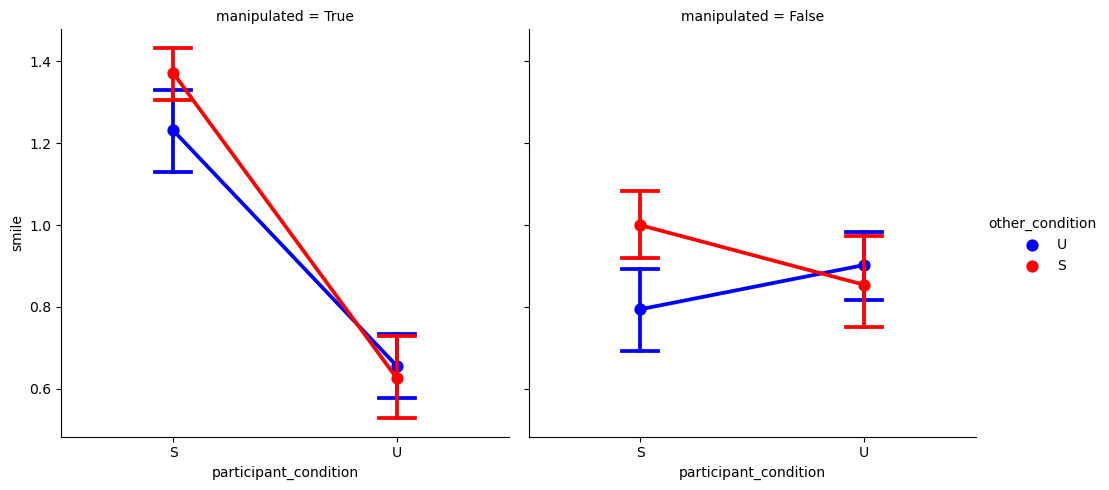

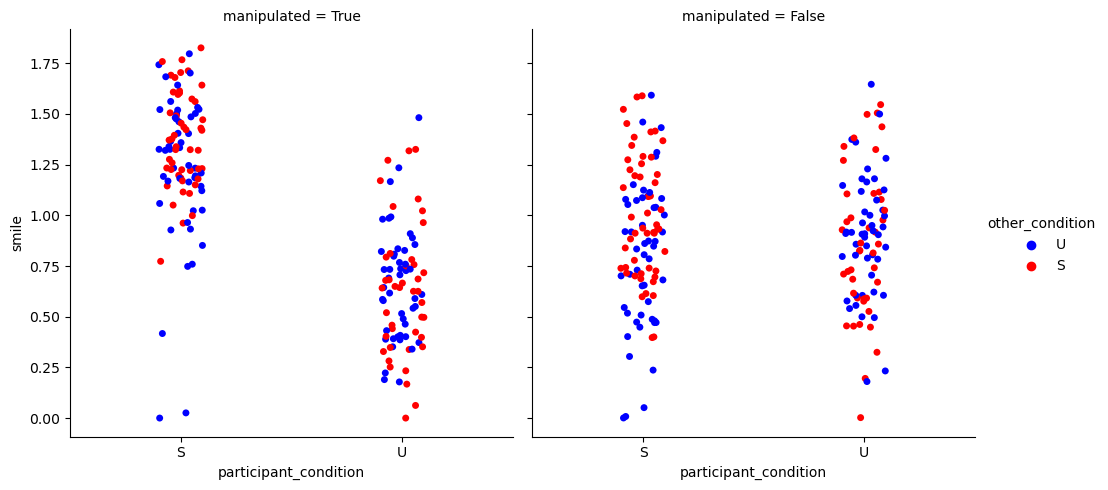

In [67]:
import seaborn as sns

smile_df = smile_df.to_pandas()
smile_df = smile_df.groupby(["sid", "user_id", "other_id", "participant_condition", "other_condition", "manipulated"]).mean(numeric_only=True).reset_index()


sns.catplot(x= "participant_condition"
            , y="smile"
            , hue="other_condition"
            , col="manipulated"
            , data=smile_df
            , kind="point"
            , palette=sns.color_palette(['blue', 'red'])
            , col_order=[True, False]
            , order=["S", "U"]
            , capsize=.16

            )

sns.catplot(x= "participant_condition"
            , y="smile"
            , hue="other_condition"
            , col="manipulated"
            , data=smile_df
            , palette=sns.color_palette(['blue', 'red'])
            , col_order=[True, False]
            , order=["S", "U"]
            )



/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


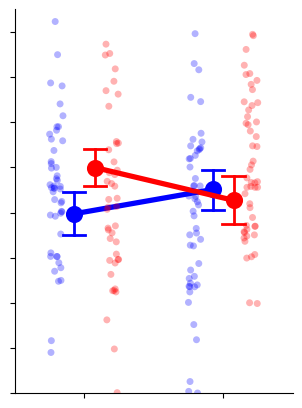

In [68]:
df_analysis = smile_df.loc[smile_df["manipulated"] == False]


g = sns.catplot( x="participant_condition", y="smile", units="user_id"
                    , height=4.6
                    , aspect=0.8
                    , data=df_analysis
                    , kind="point"
                    , capsize=.16
                    , hue="other_condition"
                    , legend=False
                    , scale=1.4
                    , dodge= 0.15
                    , errwidth=2
                    , order=["S", "U"]
                    , palette= sns.color_palette(["blue", "red"])
            )

# Add individual measure points
sns.stripplot(x="participant_condition", y="smile"
                , data=df_analysis
                , hue="other_condition", dodge=0.15, size=5, alpha=0.3
                , palette=["blue", "red"]
                , legend=False
                )    
    
g.set(ylim=(0, 1.7))

plt.savefig("plots/facial_mimicry_legend.pdf", bbox_inches='tight')
g.set(xticklabels=[], yticklabels=[], title='',xlabel=None, ylabel=None)
plt.savefig("plots/facial_mimicry.pdf", bbox_inches='tight')

# Synchrony

In [73]:
#Import data
smile_df = pl.read_csv("../data/face_data/mediapipe_results/all_au_BU.csv"
                          , columns=["sid", "user_id", "other_id", "dyad", "recording_nb", "participant_condition", "other_condition", "manipulated", "mouthSmileRight", "mouthSmileLeft", "frame" ]
                        )

In [74]:
#Import data
smile_df = pl.read_csv("../data/face_data/mediapipe_results/all_au.csv"
                          , columns=["sid", "user_id", "other_id", "dyad", "recording_nb", "participant_condition", "other_condition", "manipulated", "mouthSmileRight", "mouthSmileLeft", "frame" ]
                        )

#Prepare data for merge
smile_df = smile_df.with_columns(
    smile = smile_df["mouthSmileRight"] + smile_df["mouthSmileLeft"]
    )

#preapre data
idx= ["sid", "user_id", "other_id", "participant_condition", "other_condition", "manipulated", "dyad", "recording_nb", "frame"]
au_df = smile_df.groupby(idx).mean().sort(idx).to_pandas()
au_df.head()

/var/folders/g5/mqbcmmn575z0s3c021r942c80000gp/T/ipykernel_74705/3664374628.py:13: DeprecationWarning: `groupby` is deprecated. It has been renamed to `group_by`.
  au_df = smile_df.groupby(idx).mean().sort(idx).to_pandas()


,sid,user_id,other_id,participant_condition,other_condition,manipulated,dyad,recording_nb,frame,mouthSmileLeft,mouthSmileRight,smile
0,mkprolific_participant_real_21,mkprolific_participant_real_21p1,mkprolific_participant_real_21p5,U,U,False,p1p5,1,0.0,0.04,0.02,0.06
1,mkprolific_participant_real_21,mkprolific_participant_real_21p1,mkprolific_participant_real_21p5,U,U,False,p1p5,1,1.0,0.04,0.02,0.06
2,mkprolific_participant_real_21,mkprolific_participant_real_21p1,mkprolific_participant_real_21p5,U,U,False,p1p5,1,2.0,0.03,0.02,0.05
3,mkprolific_participant_real_21,mkprolific_participant_real_21p1,mkprolific_participant_real_21p5,U,U,False,p1p5,1,3.0,0.03,0.02,0.05
4,mkprolific_participant_real_21,mkprolific_participant_real_21p1,mkprolific_participant_real_21p5,U,U,False,p1p5,1,4.0,0.03,0.02,0.05


In [75]:
#define global features
other_manipulations = [True, False]
source_features = ["smile"]
target_features = ["smile"]

In [76]:
#import correct interactions (where recording was smooth and uninterrupted for all participants)
import pickle

with open('../data/correct_interactions.pickle', 'rb') as handle:
    correct_interactions = pickle.load(handle)

print("Found "+ str(len(correct_interactions)) + " correct interactions")

Found 113 correct interactions


In [77]:
#Both manipulated with the same value
lag = 300 # 10 seconds before and 10 seconds after
nb_min_samples = 1800 #atleast 1 minute per interaction

mi_df = pd.DataFrame()
df_lags = pd.DataFrame()
for other_manipulated in other_manipulations:
    for (sid, participant_manipulated, dyad, user_id), dyad_df in au_df.groupby(["sid", "manipulated", "dyad", "user_id"]):
        
        #if participant_manipulated == True:
        #    continue
        
        #Check if interaction was recorded correctly (4 recordings in total).
        found=False
        for interaction in correct_interactions:
            if sid == interaction[0] and dyad == interaction[1]:
                found = True
                break
        if not found:
            #print("Skipping not correct recording - dyad : " + dyad + " sid : " + sid)
            continue
            
        #Prepare participants' time series
        participant_df = dyad_df.loc[dyad_df["user_id"] == user_id]
        participant_df = participant_df.ffill(axis="rows")
        participant_df = participant_df.bfill(axis="rows")
        
        other_id = participant_df["other_id"]
        nulls = np.unique(other_id.isnull())
        if len(nulls)==1 and nulls[0]:
            continue

        other_id = np.unique(other_id)[0]    
        partner_df = au_df.loc[au_df["user_id"] == other_id]
        partner_df = partner_df.loc[partner_df["dyad"] == dyad]    
        partner_df = partner_df.loc[partner_df["manipulated"] == other_manipulated]        
        partner_df = partner_df.ffill(axis="rows")
        partner_df = partner_df.bfill(axis="rows")
        if not len(partner_df)>0:
            continue


        for source_feature in source_features:
            for target_feature in target_features:    

                #preapre participant time series
                X = participant_df[source_feature].values

                #preapre target time series
                y = partner_df[target_feature].values

                if len(y)==0 or len(X) ==0 or len(y)< nb_min_samples or len(X)< nb_min_samples:
                    continue

                #Keep only the same number of samples for both
                max = np.min([len(X), len(y)])
                X = X[0:max]
                y = y[0:max]

                #cross-correlation
                corr_X = [(val-np.nanmean(X))/np.nanstd(X) for val in X]
                corr_y = [(val-np.nanmean(y))/np.nanstd(y) for val in y]
                corr = signal.correlate(corr_X, corr_y, mode='same') 
                corr = corr  / len(X)

                #Select only cross correaltion between +/- lag
                selected_corr = corr[round(len(corr)/2 - lag): round(len(corr)/2 + lag)]
                pears_r, p = stats.pearsonr(corr_X, corr_y)
                max_corr = np.arctanh(np.nanmax(selected_corr))

                #Compute MI
                X = X.reshape(-1,1)    
                mi = mutual_info_regression(X=X, y=y
                                   , discrete_features = 'auto'
                                   , n_neighbors = 60
                                   , copy = True
                                   , random_state=None
                               )

                #Save results to a DataFrame
                aux_df = pd.DataFrame()
                aux_df["source_feature"]           = [source_feature]
                aux_df["target_feature"]           = [target_feature]
                aux_df["other_id"]                 = [other_id]
                aux_df["user_id"]                  = [user_id]
                aux_df["participant_manipulated"]  = [participant_manipulated]
                aux_df["other_manipulated"]        = [other_manipulated]
                aux_df["dyad"]                     = [dyad]
                aux_df["sid"]                      = [sid]
                aux_df["mi"]                       = mi
                aux_df["max_corr"]                 = [max_corr]

                aux_lags_df = pd.DataFrame()
                aux_lags_df["lag"]  = range(2*lag)
                aux_lags_df["lag"]  = aux_lags_df["lag"]-lag
                aux_lags_df["corr"] = selected_corr
                aux_lags_df["dyad"]                     = [dyad for i in range(len(aux_lags_df))]    
                aux_lags_df["source_feature"]           = [source_feature for i in range(len(aux_lags_df))]
                aux_lags_df["target_feature"]           = [target_feature for i in range(len(aux_lags_df))]
                aux_lags_df["participant_manipulated"]  = [participant_manipulated for i in range(len(aux_lags_df))]
                aux_lags_df["other_id"]                 = [other_id for i in range(len(aux_lags_df))]
                aux_lags_df["sid"]                      = [sid for i in range(len(aux_lags_df))]
                aux_lags_df["user_id"]                  = [user_id for i in range(len(aux_lags_df))]
                aux_lags_df["other_manipulated"]        = [other_manipulated for i in range(len(aux_lags_df))]            
                df_lags = pd.concat([df_lags, aux_lags_df])

                mi_df = pd.concat([mi_df, aux_df])

In [78]:
mi_df   = mi_df.merge(behavior_df.to_pandas()    , on=["sid", "dyad", "user_id", "other_id"], how="left")
df_lags = df_lags.merge(behavior_df.to_pandas()  , on=["sid", "dyad", "user_id", "other_id"], how="left")

In [79]:
mi_df.to_csv("../data/face_data/mediapipe_results/mi_df.csv")
df_lags.to_csv("../data/face_data/mediapipe_results/df_lags.csv")

## Analysis

In [80]:
mi_df = pd.read_csv("../data/face_data/mediapipe_results/mi_df.csv")
df_lags = pd.read_csv("../data/face_data/mediapipe_results/df_lags.csv")

/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_

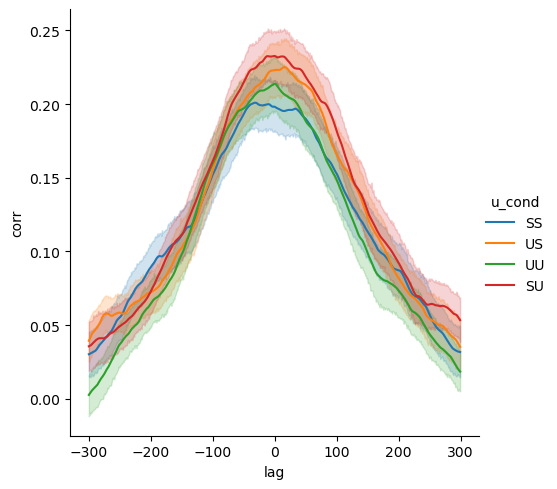

In [81]:
df_lags["u_cond"] = df_lags["participant_condition"] + df_lags["other_condition"]

df_analysis = df_lags

df_analysis = df_analysis.loc[df_analysis["participant_manipulated"] == False]

df_analysis = df_analysis.loc[df_analysis["other_manipulated"] == True]

df_analysis = df_analysis.groupby(["lag", "user_id", "participant_condition", "other_condition", "u_cond"]).mean(numeric_only=True).reset_index()


sns.relplot(x="lag", y="corr", hue="u_cond", data= df_analysis, kind="line", ci=68)

/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_

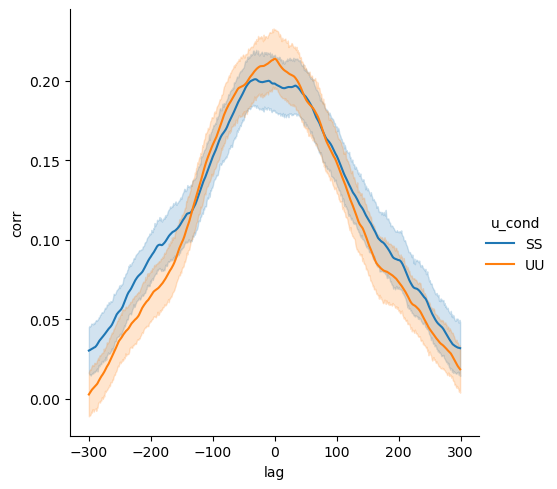

In [82]:
df_lags["u_cond"] = df_lags["participant_condition"] + df_lags["other_condition"]

df_analysis = df_lags

df_analysis = df_analysis.loc[df_analysis["participant_manipulated"] == False]

df_analysis = df_analysis.loc[df_analysis["other_manipulated"] == True]

df_analysis = df_analysis.loc[df_analysis["u_cond"] != "US"]

df_analysis = df_analysis.loc[df_analysis["u_cond"] != "SU"]

df_analysis = df_analysis.groupby(["lag", "user_id", "participant_condition", "other_condition", "u_cond"]).mean(numeric_only=True).reset_index()


sns.relplot(x="lag", y="corr", hue="u_cond", data= df_analysis, kind="line", ci=68)